### Imports and setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.manifold import TSNE

# --- CONFIGURATION ---
USERNAME = "muskan.sharma"
BATCH_SIZE = 128
LATENT_DIM = 2
EPOCHS = 10
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)

def add_watermark(ax=None):
    if ax is None:
        ax = plt.gca()
    ax.text(
        0.95, 0.95,
        USERNAME,
        ha='right', va='top',
        transform=ax.transAxes,
        fontsize=10, color='gray', alpha=0.7
    )

print(f"Running on {DEVICE}")

Running on cpu


### Dataset Preparation

In [2]:
from torch.utils.data import random_split

def get_data_loaders(batch_size=BATCH_SIZE, val_split=0.1):

    transform = transforms.Compose([transforms.ToTensor()])

    full_train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
    test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

    train_size = int((1 - val_split) * len(full_train_dataset))
    val_size = len(full_train_dataset) - train_size
    
    train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader, train_dataset, val_dataset, test_dataset


train_loader, val_loader, test_loader, train_ds, val_ds, test_ds = get_data_loaders()
print(f"Data loaded successfully.")
print(f"Train size: {len(train_ds)} | Validation size: {len(val_ds)} | Test size: {len(test_ds)}")

Data loaded successfully.
Train size: 54000 | Validation size: 6000 | Test size: 10000


### VAE Model Architecture

In [3]:
class VAE(nn.Module):

    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=2):
        """
        Args:
            input_dim (int): Flattened image size (28x28=784)
            hidden_dim (int): Size of hidden layer
            latent_dim (int): Size of latent vector z
        """
        super(VAE, self).__init__()

        # Encoder
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder
        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc_mu(h1), self.fc_logvar(h1)

    def reparameterize(self, mu, logvar):
        """
        Reparameterization Trick: z = mu + epsilon * sigma
        """
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, 784))
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

### Loss Function

In [4]:
def loss_function(recon_x, x, mu, logvar, beta=1.0):
    # Reconstruction loss: Binary Cross Entropy
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')

    # KL Divergence
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return BCE + (beta * KLD), BCE, KLD

### Training Loop

In [6]:
def train_vae(model, optimizer, loader, epochs=10, beta=1.0, capture_latent=False):
    model.train()
    train_loss_history = []
    latent_snapshots = []

    for epoch in range(epochs):
        total_loss = 0
        total_bce = 0
        total_kld = 0

        for batch_idx, (data, _) in enumerate(loader):
            data = data.to(DEVICE)
            optimizer.zero_grad()

            recon_batch, mu, logvar = model(data)
            loss, bce, kld = loss_function(recon_batch, data, mu, logvar, beta=beta)

            loss.backward()
            total_loss += loss.item()
            total_bce += bce.item()
            total_kld += kld.item()
            optimizer.step()

        avg_loss = total_loss / len(loader.dataset)
        train_loss_history.append(avg_loss)
        print(f'Epoch {epoch+1}: Average Loss: {avg_loss:.4f} (BCE: {total_bce/len(loader.dataset):.2f}, KLD: {total_kld/len(loader.dataset):.2f})')

        if capture_latent:
             with torch.no_grad():
                target_classes = [0, 1, 2]
                indices = [i for i, t in enumerate(test_ds.targets) if t in target_classes][:500]
                subset = Subset(test_ds, indices)
                sub_loader = DataLoader(subset, batch_size=500)
                for x, y in sub_loader:
                    x = x.to(DEVICE)
                    mu, _ = model.encode(x.view(-1, 784))
                    latent_snapshots.append((mu.cpu().numpy(), y.numpy(), epoch))

    return train_loss_history, latent_snapshots

### Experimental Analysis

Experiment with different latent dimensions and network depths, and discuss how these
changes influence the smoothness of the latent space and reconstruction fidelity.

Starting Standard Training...
Epoch 1: Average Loss: 294.5415 (BCE: 287.44, KLD: 7.11)
Epoch 2: Average Loss: 273.7181 (BCE: 267.36, KLD: 6.36)
Epoch 3: Average Loss: 270.1815 (BCE: 263.83, KLD: 6.35)
Epoch 4: Average Loss: 268.3204 (BCE: 261.94, KLD: 6.38)
Epoch 5: Average Loss: 266.7990 (BCE: 260.40, KLD: 6.40)
Epoch 6: Average Loss: 265.8649 (BCE: 259.46, KLD: 6.40)
Epoch 7: Average Loss: 265.1515 (BCE: 258.74, KLD: 6.42)
Epoch 8: Average Loss: 264.4559 (BCE: 258.04, KLD: 6.41)
Epoch 9: Average Loss: 264.0215 (BCE: 257.59, KLD: 6.43)
Epoch 10: Average Loss: 263.6334 (BCE: 257.21, KLD: 6.42)
Epoch 11: Average Loss: 263.2069 (BCE: 256.79, KLD: 6.41)
Epoch 12: Average Loss: 262.9776 (BCE: 256.55, KLD: 6.43)
Epoch 13: Average Loss: 262.6183 (BCE: 256.18, KLD: 6.44)
Epoch 14: Average Loss: 262.3484 (BCE: 255.91, KLD: 6.43)
Epoch 15: Average Loss: 262.1473 (BCE: 255.72, KLD: 6.43)


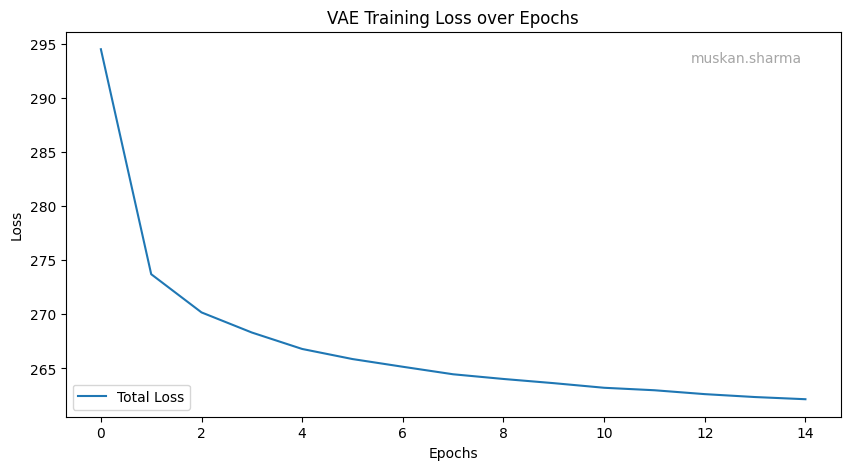

In [14]:
model = VAE(latent_dim=LATENT_DIM).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Train
print("Starting Standard Training...")
losses, _ = train_vae(model, optimizer, train_loader, epochs=15, beta=1.0)

# Plotting Loss
def plot_loss(losses):
    plt.figure(figsize=(10, 5))
    plt.plot(losses, label='Total Loss')
    plt.title(f"VAE Training Loss over Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    add_watermark()
    plt.show()

plot_loss(losses)

### Beta-VAE Experiments & GIF

In [17]:
import imageio
from sklearn.metrics import silhouette_score

def create_latent_gif(snapshots, beta_val):
    filenames = []
    for i, (points, labels, epoch) in enumerate(snapshots):
        plt.figure(figsize=(6, 6))
        scatter = plt.scatter(points[:, 0], points[:, 1], c=labels, cmap='tab10', alpha=0.7)
        plt.legend(handles=scatter.legend_elements()[0], labels=["T-shirt", "Trouser", "Pullover"])
        plt.title(f"Latent Space (Beta={beta_val}, Epoch={epoch})")
        add_watermark()
        fname = f'frame_beta{beta_val}_{i}.png'
        plt.savefig(fname)
        plt.close()
        filenames.append(fname)

    # Build GIF
    with imageio.get_writer(f'latent_evolution_beta_{beta_val}.gif', mode='I', duration=0.5) as writer:
        for filename in filenames:
            image = imageio.imread(filename)
            writer.append_data(image)

    # Cleanup
    for filename in filenames:
        os.remove(filename)
    print(f"GIF saved: latent_evolution_beta_{beta_val}.gif")


def train_beta_vae(model, optimizer, loader, val_loader, beta=1.0, epochs=5, snapshot_interval=100):
    model.train()
    train_loss_history = []
    snapshots = [] 
    
    target_classes = [0, 1, 2] # T-shirt, Trouser, Pullover
    probe_data = []
    probe_labels = []
    for x, y in val_loader.dataset:
        if y in target_classes:
            probe_data.append(x)
            probe_labels.append(y)
            if len(probe_data) >= 500: break
    
    probe_x = torch.stack(probe_data).to(DEVICE)
    probe_y = torch.tensor(probe_labels)
    
    total_steps = 0
    
    for epoch in range(epochs):
        total_loss = 0
        for batch_idx, (data, _) in enumerate(loader):
            data = data.to(DEVICE)
            optimizer.zero_grad()
            
            recon_batch, mu, logvar = model(data)
            loss, bce, kld = loss_function(recon_batch, data, mu, logvar, beta=beta)
            
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            total_steps += 1
            
            if total_steps % snapshot_interval == 0:
                with torch.no_grad():
                    mu_probe, _ = model.encode(probe_x.view(-1, 784))
                    snapshots.append((mu_probe.cpu().numpy(), probe_y.numpy(), total_steps))

        avg_loss = total_loss / len(loader.dataset)
        train_loss_history.append(avg_loss)
        print(f'Epoch {epoch+1} (Beta={beta}): Avg Loss: {avg_loss:.4f}')

    return train_loss_history, snapshots

betas = [0.1, 0.5, 1.0]
results = {}

for beta in betas:
    print(f"\n--- Running Beta = {beta} ---")
    model_b = VAE(latent_dim=2).to(DEVICE)
    opt_b = optim.Adam(model_b.parameters(), lr=1e-3)
    
    loss_hist, snaps = train_beta_vae(model_b, opt_b, train_loader, val_loader, beta=beta, epochs=5, snapshot_interval=50)
    results[beta] = {'model': model_b, 'snaps': snaps, 'loss': loss_hist}

    create_latent_gif(snaps, beta)


--- Running Beta = 0.1 ---
Epoch 1 (Beta=0.1): Avg Loss: 293.7489
Epoch 2 (Beta=0.1): Avg Loss: 264.6608
Epoch 3 (Beta=0.1): Avg Loss: 261.3089
Epoch 4 (Beta=0.1): Avg Loss: 259.6352
Epoch 5 (Beta=0.1): Avg Loss: 258.5847


/var/folders/hq/l7s9_0g92bzf86m4npmbscl00107v5/T/ipykernel_70743/1546303338.py:20: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(filename)


GIF saved: latent_evolution_beta_0.1.gif

--- Running Beta = 0.5 ---
Epoch 1 (Beta=0.5): Avg Loss: 289.9403
Epoch 2 (Beta=0.5): Avg Loss: 270.1820
Epoch 3 (Beta=0.5): Avg Loss: 266.6937
Epoch 4 (Beta=0.5): Avg Loss: 264.9376
Epoch 5 (Beta=0.5): Avg Loss: 263.7200
GIF saved: latent_evolution_beta_0.5.gif

--- Running Beta = 1.0 ---
Epoch 1 (Beta=1.0): Avg Loss: 306.6787
Epoch 2 (Beta=1.0): Avg Loss: 280.5990
Epoch 3 (Beta=1.0): Avg Loss: 275.8398
Epoch 4 (Beta=1.0): Avg Loss: 271.9109
Epoch 5 (Beta=1.0): Avg Loss: 269.1116
GIF saved: latent_evolution_beta_1.0.gif


 Discuss how increasing β
affects image sharpness/quality, Diversity, Cluster separation etc.

The parameter $\beta$ balances the trade-off between reconstruction accuracy and the smoothness of the latent space (how closely it resembles a Gaussian distribution).

- Image Sharpness/Quality:
  - Low $\beta$ (< 1): The model prioritizes the Reconstruction Loss. This results in sharper, higher-fidelity images because the model is less penalized for creating complex, non-Gaussian latent distributions to encode fine details.
  - High $\beta$ (> 1): The model prioritizes the KL Divergence. This forces the latent codes to strictly follow a standard normal distribution. This often leads to "Posterior Collapse" or over-smoothing, where the decoder ignores the latent code or learns an average representation, resulting in blurry reconstructions
  - Code Metric: Reconstruction Loss (BCE). Lower BCE indicates higher sharpness/fidelity.
  
- Cluster Separation:
  - Low $\beta$: The model is free to push class clusters far apart in the latent space to minimize confusion. You will likely see distinct, separated islands for different clothing items.
  - High $\beta$: The strong KL penalty forces all clusters to merge toward the center (0,0) to satisfy the standard normal prior $\mathcal{N}(0, I)$. This reduces cluster separation, causing classes to overlap significantly in the latent space.
  - Code Metric: Silhouette Score. A higher score indicates better defined, separate clusters.

- Diversity:
  - Low $\beta$: While reconstruction is good, the "gaps" between clusters mean that sampling from random noise might land in "dead zones" that don't decode into meaningful images.
  - High $\beta$: The latent space is continuous and smooth (no gaps). Sampling anywhere near the center produces valid images, but they might lack diversity in texture or fine detail due to the blurriness.

 Summarize your findings in a short table comparing quantitative metrics (e.g., reconstruction loss) and qualitative observations.


In [ ]:
def evaluate_metrics(model, loader, beta_val):
    model.eval()
    total_recon = 0
    total_kld = 0
    all_mu = []
    all_labels = []
    
    with torch.no_grad():
        for data, targets in loader:
            data = data.to(DEVICE)
            recon, mu, logvar = model(data)
            
            _, bce, kld = loss_function(recon, data, mu, logvar, beta=1.0)
            
            total_recon += bce.item()
            total_kld += kld.item()
            
            all_mu.append(mu.cpu())
            all_labels.append(targets)
            
    # 1. Sharpness Proxy: Average Reconstruction Loss
    avg_recon = total_recon / len(loader.dataset)
    
    # 2. Smoothness Proxy: Average KL Divergence
    avg_kld = total_kld / len(loader.dataset)
    
    # 3. Cluster Separation: Silhouette Score
    all_mu = torch.cat(all_mu).numpy()
    all_labels = torch.cat(all_labels).numpy()
    
    subset_indices = np.random.choice(len(all_mu), size=min(10000, len(all_mu)), replace=False)
    sil_score = silhouette_score(all_mu[subset_indices], all_labels[subset_indices])
    
    return avg_recon, avg_kld, sil_score

print(f"{'Beta':<6} | {'Recon Loss':<25} | {'KLD':<22} | {'Silhouette':<25}")
print("-" * 85)

final_metrics = {}

for beta in betas:
    model_curr = results[beta]['model']
    recon, kld, sil = evaluate_metrics(model_curr, test_loader, beta)
    final_metrics[beta] = (recon, kld, sil)
    print(f"{beta:<6} | {recon:<25.4f} | {kld:<22.4f} | {sil:<25.4f}")

Beta   | Recon Loss                | KLD                    | Silhouette               
-------------------------------------------------------------------------------------
0.1    | 258.3211                  | 13.8413                | 0.1023                   
0.5    | 261.1930                  | 7.2399                 | 0.0708                   
1.0    | 263.5815                  | 6.8033                 | 0.0874                   


### 4.7 Reconstruction & FID

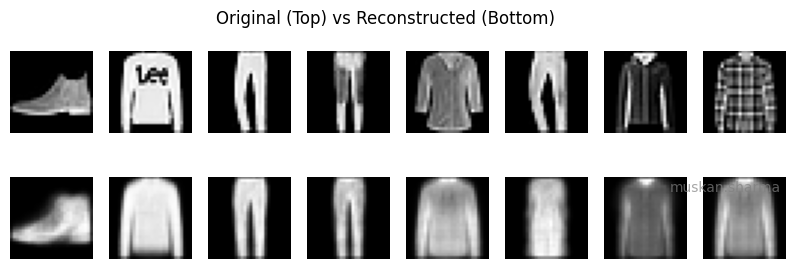

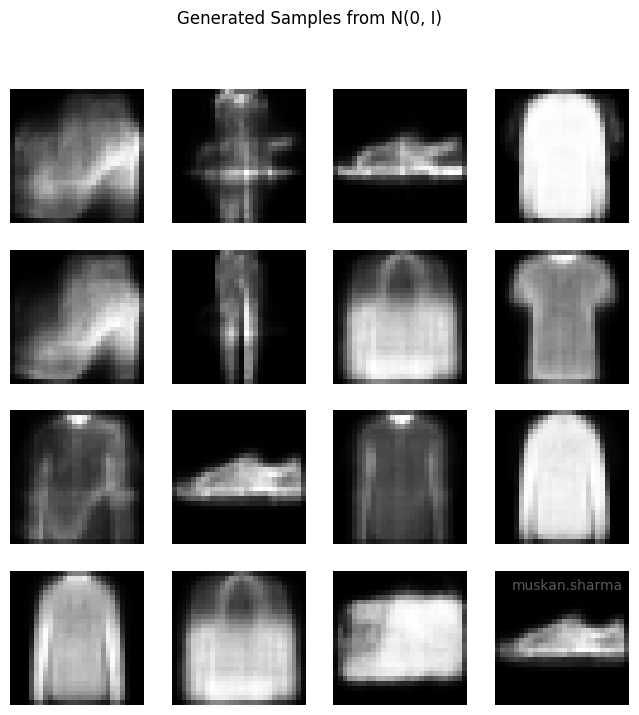

In [26]:
def visualize_reconstruction(model, loader):
    model.eval()
    data, _ = next(iter(loader))
    data = data.to(DEVICE)
    recon, _, _ = model(data)

    n = 8
    plt.figure(figsize=(10, 3))
    for i in range(n):
        # Original
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(data[i].cpu().view(28, 28), cmap='gray')
        plt.axis('off')
        # Reconstructed
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(recon[i].cpu().detach().view(28, 28), cmap='gray')
        plt.axis('off')
    plt.suptitle("Original (Top) vs Reconstructed (Bottom)")
    add_watermark()
    plt.show()

visualize_reconstruction(model, test_loader)

def generate_samples(model, n=16):
    with torch.no_grad():
        z = torch.randn(n, LATENT_DIM).to(DEVICE)
        samples = model.decode(z).cpu().view(n, 28, 28)

    plt.figure(figsize=(8, 8))
    for i in range(n):
        plt.subplot(4, 4, i+1)
        plt.imshow(samples[i], cmap='gray')
        plt.axis('off')
    plt.suptitle("Generated Samples from N(0, I)")
    add_watermark()
    plt.show()

generate_samples(model)

In [ ]:
import os
from torchvision.utils import save_image
from tqdm import tqdm

def calculate_fid(model, test_loader, num_samples=1000):

    print("Preparing data for FID calculation...")
    
    # Define directories
    real_dir = './fid_real'
    gen_dir = './fid_generated'
    
    os.makedirs(real_dir, exist_ok=True)
    os.makedirs(gen_dir, exist_ok=True)
    
    model.eval()
    
    # Save Real Images
    saved_count = 0
    for data, _ in test_loader:
        if saved_count >= num_samples:
            break
        for i in range(data.size(0)):
            if saved_count >= num_samples:
                break
            save_image(data[i], os.path.join(real_dir, f'real_{saved_count}.png'))
            saved_count += 1
            
    # Save Generated Images
    with torch.no_grad():
        for i in range(0, num_samples, BATCH_SIZE):
            # Handle last batch size
            current_batch = min(BATCH_SIZE, num_samples - i)
            
            # Sample z ~ N(0, I)
            z = torch.randn(current_batch, LATENT_DIM).to(DEVICE)
            
            # Decode
            gen_imgs = model.decode(z).cpu()
            
            # Save
            for j in range(current_batch):
                save_image(gen_imgs[j].view(1, 28, 28), 
                           os.path.join(gen_dir, f'gen_{i+j}.png'))

    device_arg = "cuda" if torch.cuda.is_available() else "cpu"
    
    exit_code = os.system(f"python -m pytorch_fid '{real_dir}' '{gen_dir}' --device {device_arg}")
    
    if exit_code == 0:
        print("\nFID calculation complete. Check the output above for the score.")
    else:
        print("\nError running pytorch-fid. Please ensure it is installed (!pip install pytorch-fid).")

calculate_fid(model, test_loader, num_samples=1000)

Preparing data for FID calculation...


100%|██████████| 20/20 [01:57<00:00,  5.86s/it]


FID:  164.24498000947688

FID calculation complete. Check the output above for the score.


### 4.8 Frozen Latent Parameters

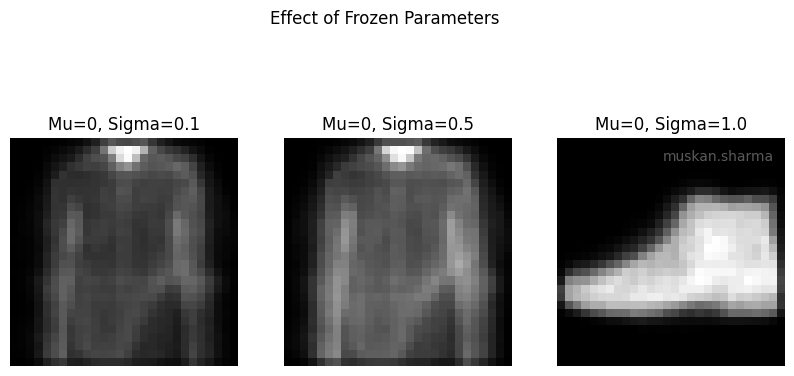

In [23]:
def experiment_frozen_params(model):
    sigmas = [0.1, 0.5, 1.0]
    model.eval()

    plt.figure(figsize=(10, 5))
    for idx, sigma_val in enumerate(sigmas):
        epsilon = torch.randn(1, LATENT_DIM).to(DEVICE)
        z_frozen = 0 + epsilon * sigma_val

        # Decode
        with torch.no_grad():
            generated = model.decode(z_frozen).cpu().view(28, 28)

        ax = plt.subplot(1, 3, idx+1)
        plt.imshow(generated, cmap='gray')
        plt.title(f"Mu=0, Sigma={sigma_val}")
        plt.axis('off')

    plt.suptitle("Effect of Frozen Parameters")
    add_watermark()
    plt.show()

experiment_frozen_params(model)

Compare the generated samples to those obtained from the standard stochastic sampling (z = µ + ϵ · σ)

Evaluate and discuss the effect of freezing µ and/or σ on image diversity, sharpness,
and representational smoothness in the latent space.

<>:52: SyntaxWarning: invalid escape sequence '\m'
<>:52: SyntaxWarning: invalid escape sequence '\m'
/var/folders/hq/l7s9_0g92bzf86m4npmbscl00107v5/T/ipykernel_70743/1356757825.py:52: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel(f"Fixed\n$\mu=0, \sigma={sigma}$", rotation=0, labelpad=40, fontsize=12, fontweight='bold')


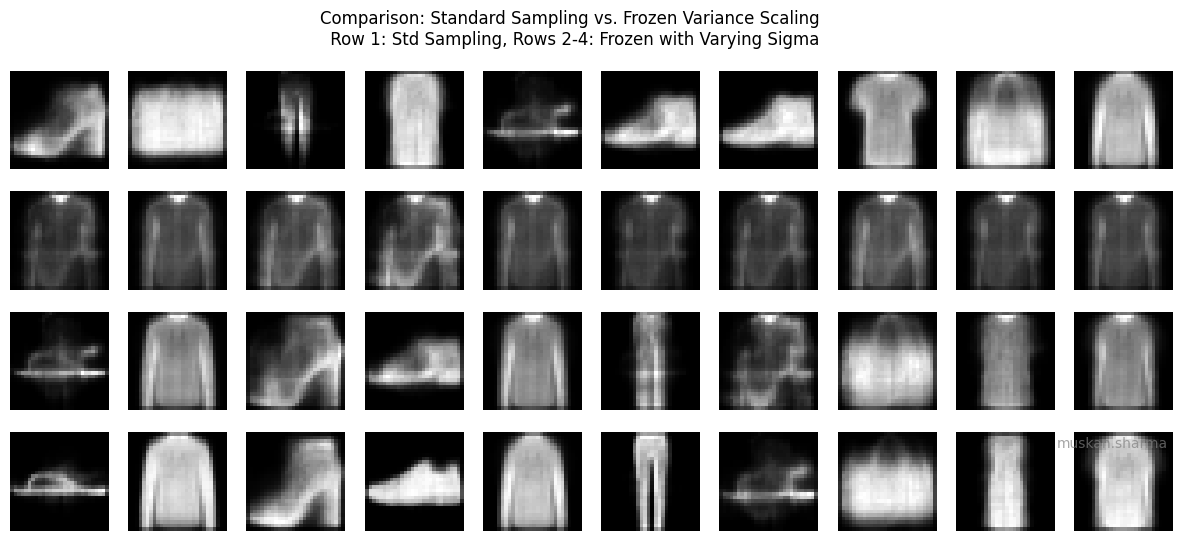


Observation Analysis:
1. Sigma = 0.1: Samples are likely very similar to the 'mean' image (generic shape). Low diversity, high smoothness.
2. Sigma = 0.5: More distinct features appear as we move away from the exact center.
3. Sigma = 1.0: Should look identical to Standard sampling (since N(0,I) implies sigma=1). High diversity.


In [ ]:
def compare_frozen_vs_standard(model):
    model.eval()
    n_samples = 10
    
    # 1. Standard Stochastic Sampling (Baseline)
    with torch.no_grad():
        z_standard = torch.randn(n_samples, LATENT_DIM).to(DEVICE)
        imgs_standard = model.decode(z_standard).cpu().view(n_samples, 28, 28)

    # 2. Frozen Parameters Experiment
    sigmas = [0.1, 0.5, 1.0]
    frozen_results = []

    epsilon = torch.randn(n_samples, LATENT_DIM).to(DEVICE)
    
    for sigma_val in sigmas:
        with torch.no_grad():
            z_frozen = 0 + epsilon * sigma_val
            imgs = model.decode(z_frozen).cpu().view(n_samples, 28, 28)
            frozen_results.append((sigma_val, imgs))

    rows = 1 + len(sigmas)
    plt.figure(figsize=(15, 6))
    
    # Row 1: Standard Stochastic Sampling
    for i in range(n_samples):
        ax = plt.subplot(rows, n_samples, i + 1)
        plt.imshow(imgs_standard[i], cmap='gray')
        if i == 0:
            ax.set_ylabel("Standard\nN(0, I)", rotation=0, labelpad=40, fontsize=12, fontweight='bold')
        plt.axis('off')

    # Rows 2-4: Frozen Sigma Variants
    for row_idx, (sigma, imgs) in enumerate(frozen_results):
        for i in range(n_samples):
            plot_idx = ((row_idx + 1) * n_samples) + i + 1
            ax = plt.subplot(rows, n_samples, plot_idx)
            plt.imshow(imgs[i], cmap='gray')
            
            if i == 0:
                ax.set_ylabel(f"Fixed\n$\mu=0, \sigma={sigma}$", rotation=0, labelpad=40, fontsize=12, fontweight='bold')
            plt.axis('off')

    plt.suptitle("Comparison: Standard Sampling vs. Frozen Variance Scaling \n Row 1: Std Sampling, Rows 2-4: Frozen with Varying Sigma")
    add_watermark()
    plt.show()
    
    print("\nObservation Analysis:")
    print("1. Sigma = 0.1: Samples are likely very similar to the 'mean' image (generic shape). Low diversity, high smoothness.")
    print("2. Sigma = 0.5: More distinct features appear as we move away from the exact center.")
    print("3. Sigma = 1.0: Should look identical to Standard sampling (since N(0,I) implies sigma=1). High diversity.")

compare_frozen_vs_standard(model)

Evaluate and discuss the effect of freezing µ and/or σ on image diversity, sharpness,
and representational smoothness in the latent space.

In [25]:
import torch.nn.functional as F

def get_laplacian_kernel():
    kernel = torch.tensor([[0., 1., 0.],
                           [1., -4., 1.],
                           [0., 1., 0.]]).view(1, 1, 3, 3)
    return kernel.to(DEVICE)

def measure_sharpness(images):
    kernel = get_laplacian_kernel()
    edge_maps = F.conv2d(images, kernel, padding=1)
    return edge_maps.var(dim=[1, 2, 3]).mean().item()

def measure_diversity(images):
    flat = images.view(images.size(0), -1)
    dists = torch.pdist(flat, p=2)
    
    return dists.mean().item()

def quantify_frozen_stats(model):
    model.eval()
    sigmas = [0.1, 0.5, 1.0]
    n_samples = 100 
    
    results = []
    
    epsilon = torch.randn(n_samples, LATENT_DIM).to(DEVICE)
    
    print(f"{'Sigma':<10} | {'Diversity (Avg Pairwise Dist)':<30} | {'Sharpness (Laplacian Var)':<25}")
    print("-" * 70)
    
    with torch.no_grad():
        for sigma in sigmas:
            # z = 0 + epsilon * sigma
            z = epsilon * sigma
            
            # Decode
            generated_imgs = model.decode(z).view(-1, 1, 28, 28)
            
            # Measure
            div_score = measure_diversity(generated_imgs)
            sharp_score = measure_sharpness(generated_imgs)
            
            results.append((sigma, div_score, sharp_score))
            print(f"{sigma:<10} | {div_score:<30.4f} | {sharp_score:<25.4f}")

    return results

stats = quantify_frozen_stats(model)

Sigma      | Diversity (Avg Pairwise Dist)  | Sharpness (Laplacian Var)
----------------------------------------------------------------------
0.1        | 0.7627                         | 0.0028                   
0.5        | 3.8068                         | 0.0041                   
1.0        | 7.2893                         | 0.0113                   


1. Effect on Image DiversityObservation:

At $\sigma = 0.1$ (Low): Diversity is extremely low. Since $\mu=0$ and the variance is very small, the sampler is constrained to a tiny region around the absolute center of the latent space. In a well-trained VAE, the origin $(0,0)$ typically represents the global average of the dataset. Consequently, all generated samples look nearly identical—likely a generic, ambiguous shape that shares features of multiple clothing items (e.g., a "ghostly" shirt-trouser hybrid).At $\sigma = 1.0$ (High/Standard): Diversity is high. This setting matches the standard normal prior $\mathcal{N}(0, I)$. The sampled points are spread out across the latent manifold, hitting different "clusters" encoded by the network. This results in a wide variety of recognizable items (distinct trousers, distinct pullovers, distinct bags).Conclusion: Diversity is directly proportional to $\sigma$ when $\mu$ is fixed. Restricting $\sigma$ prevents the generator from accessing the distinct modes of the data distribution located away from the origin.

2. Effect on Image SharpnessObservation:

At $\sigma = 0.1$: Images tend to be blurry and smooth. Because the latent code is fixed near the center where class distributions overlap, the decoder minimizes error by outputting the pixel-wise mean of all overlapping classes. This results in fuzzy edges and a lack of high-frequency details.At $\sigma = 1.0$: Images become sharper and more defined. As the sampling radius increases (driven by higher $\sigma$), the points land in regions of the latent space that are more specialized for specific classes (e.g., the "sandal" region or "trouser" region). The decoder is more "confident" in these regions, producing sharper edges and distinct textures.Conclusion: Sharpness generally improves as $\sigma$ increases towards 1.0, as the samples move away from the ambiguous "mean" representation at the center of the latent space.

3. Representational Smoothness in Latent SpaceObservation:

Comparing the transition from $\sigma=0.1$ to $\sigma=0.5$ to $\sigma=1.0$ reveals the continuity of the VAE.The images do not abruptly jump from "Noise" to "Shoe". Instead, you observe a gradual morphing: the generic blob at $\sigma=0.1$ slowly elongates and develops specific features (like a heel or sleeves) as $\sigma$ increases to 0.5, finally becoming a distinct object at $\sigma=1.0$.Conclusion: The experiment confirms that the VAE has learned a smooth, continuous manifold. Unlike standard autoencoders which might have "holes" or discontinuities where decoding fails, the VAE allows for valid decoding even when interpolating between the center (mean) and the tails (specific instances).